In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import glob
import cv2
import math
import numpy as np
from typing import Tuple, List

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision.models import resnet152, ResNet152_Weights
from torchvision import transforms
from tqdm import tqdm

# ----------------------------------------------------
# Utils
# ----------------------------------------------------
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

def dice_coef(pred, target, eps=1e-6):
    pred = (pred > 0.5).float()
    inter = (pred * target).sum(dim=(1,2,3))
    union = pred.sum(dim=(1,2,3)) + target.sum(dim=(1,2,3))
    return ((2*inter + eps) / (union + eps)).mean().item()

def area_based_cdr(oc_mask: torch.Tensor, od_mask: torch.Tensor, eps=1e-6):
    # oc_mask, od_mask: [B,1,H,W] (binary 0/1)
    oc_area = oc_mask.sum(dim=(1,2,3))
    od_area = od_mask.sum(dim=(1,2,3)) + eps
    return (oc_area / od_area).cpu().numpy()

def vertical_cdr(oc_mask: torch.Tensor, od_mask: torch.Tensor, eps=1e-6):
    # Approx vertical diameter via bbox height
    # returns numpy array of shape [B]
    b = oc_mask.shape[0]
    ratios = []
    oc_np = oc_mask.squeeze(1).cpu().numpy()
    od_np = od_mask.squeeze(1).cpu().numpy()
    for i in range(b):
        oc = oc_np[i].astype(np.uint8)
        od = od_np[i].astype(np.uint8)
        if oc.sum() == 0 or od.sum() == 0:
            ratios.append(0.0)
            continue
        ys, xs = np.where(oc > 0)
        oc_h = ys.max() - ys.min() + 1
        ys, xs = np.where(od > 0)
        od_h = ys.max() - ys.min() + 1 + eps
        ratios.append(float(oc_h / od_h))
    return np.array(ratios)

# ----------------------------------------------------
# Dataset with improved file handling
# ----------------------------------------------------
from PIL import Image

class FundusMultiMaskDataset(Dataset):
    def __init__(self, image_dir, mask_dir, size=512, verbose=True):
        self.size = size
        self.mask_dir = mask_dir
        self.verbose = verbose

        # Get all image files
        image_patterns = ["*.png", "*.jpg", "*.jpeg", "*.bmp", "*.tiff"]
        all_image_paths = []
        for pattern in image_patterns:
            all_image_paths.extend(glob.glob(os.path.join(image_dir, pattern)))

        # Filter images that have corresponding masks
        self.image_paths = []
        self.valid_pairs = []

        if verbose:
            print(f"Found {len(all_image_paths)} total images")
            print(f"Checking for corresponding masks in: {mask_dir}")

        for img_path in all_image_paths:
            base = os.path.splitext(os.path.basename(img_path))[0]

            # Try different possible mask directory structures
            possible_mask_dirs = [
                os.path.join(mask_dir, base),  # masks/image_name/
                mask_dir,  # masks/ (if od.png and oc.png are directly here with prefixes)
            ]

            # Try different naming conventions
            mask_found = False
            od_path = oc_path = None

            for mask_base_dir in possible_mask_dirs:
                # Try different naming patterns
                od_patterns = [
                    os.path.join(mask_base_dir, "od.png"),
                    os.path.join(mask_base_dir, f"{base}_od.png"),
                    os.path.join(mask_base_dir, f"{base}_OD.png"),
                    os.path.join(mask_base_dir, f"od_{base}.png"),
                    os.path.join(mask_base_dir, f"OD_{base}.png"),
                ]

                oc_patterns = [
                    os.path.join(mask_base_dir, "oc.png"),
                    os.path.join(mask_base_dir, f"{base}_oc.png"),
                    os.path.join(mask_base_dir, f"{base}_OC.png"),
                    os.path.join(mask_base_dir, f"oc_{base}.png"),
                    os.path.join(mask_base_dir, f"OC_{base}.png"),
                ]

                # Check all combinations
                for od_p in od_patterns:
                    for oc_p in oc_patterns:
                        if os.path.exists(od_p) and os.path.exists(oc_p):
                            od_path = od_p
                            oc_path = oc_p
                            mask_found = True
                            break
                    if mask_found:
                        break
                if mask_found:
                    break

            if mask_found:
                self.image_paths.append(img_path)
                self.valid_pairs.append((od_path, oc_path))
                if verbose and len(self.image_paths) <= 5:  # Show first few examples
                    print(f"✓ {base}: OD={od_path}, OC={oc_path}")
            else:
                if verbose:
                    print(f"✗ Missing masks for {base}")

        if verbose:
            print(f"\nFinal dataset size: {len(self.image_paths)} images with valid mask pairs")

        if len(self.image_paths) == 0:
            raise ValueError("No valid image-mask pairs found! Please check your file structure.")

        self.img_tf = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
        ])

    def __len__(self):
        return len(self.image_paths)

    def _load_mask_pair(self, idx):
        od_path, oc_path = self.valid_pairs[idx]

        try:
            od = np.array(Image.open(od_path).convert("L"), dtype=np.uint8)
            oc = np.array(Image.open(oc_path).convert("L"), dtype=np.uint8)
            return od, oc
        except Exception as e:
            raise FileNotFoundError(f"Error loading masks {od_path}, {oc_path}: {str(e)}")

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]

        # Load image
        img = cv2.imread(img_path)
        if img is None:
            raise ValueError(f"Could not load image: {img_path}")
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (self.size, self.size), interpolation=cv2.INTER_LINEAR)

        # Load masks
        od, oc = self._load_mask_pair(idx)
        od = cv2.resize(od, (self.size, self.size), interpolation=cv2.INTER_NEAREST)
        oc = cv2.resize(oc, (self.size, self.size), interpolation=cv2.INTER_NEAREST)

        # Ensure masks are binary (0 or 1)
        od = (od > 127).astype(np.float32)
        oc = (oc > 127).astype(np.float32)

        mask = np.stack([od, oc], axis=0)  # [2,H,W]
        mask = torch.from_numpy(mask).float()

        img = self.img_tf(img)

        return img, mask


# ----------------------------------------------------
# Model Components (unchanged)
# ----------------------------------------------------
class MHSA2D(nn.Module):
    """Simple Multi-Head Self Attention over flattened spatial tokens."""
    def __init__(self, dim, heads=4, dropout=0.0):
        super().__init__()
        self.heads = heads
        self.scale = (dim // heads) ** -0.5

        self.qkv = nn.Linear(dim, dim * 3)
        self.proj = nn.Linear(dim, dim)
        self.attn_drop = nn.Dropout(dropout)
        self.proj_drop = nn.Dropout(dropout)

    def forward(self, x):
        # x: [B, C, H, W] -> flatten spatial
        b, c, h, w = x.shape
        n = h * w
        x_flat = x.view(b, c, n).permute(0, 2, 1)  # [B, N, C]

        qkv = self.qkv(x_flat).chunk(3, dim=-1)    # 3 x [B, N, C]
        q, k, v = map(lambda t: t.view(b, -1, self.heads, c // self.heads).transpose(1,2), qkv)  # [B, heads, N, dim/h]

        attn = (q @ k.transpose(-2, -1)) * self.scale  # [B, heads, N, N]
        attn = attn.softmax(dim=-1)
        attn = self.attn_drop(attn)

        out = attn @ v  # [B, heads, N, dim/h]
        out = out.transpose(1,2).contiguous().view(b, n, c)  # [B, N, C]
        out = self.proj_drop(self.proj(out))  # [B, N, C]

        out = out.permute(0,2,1).view(b, c, h, w)
        return out

class ASPP(nn.Module):
    """DeepLabV3 ASPP module."""
    def __init__(self, in_ch, out_ch=256, atrous_rates=(12, 24, 36)):
        super().__init__()
        modules = []
        modules.append(nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        ))

        for r in atrous_rates:
            modules.append(nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 3, padding=r, dilation=r, bias=False),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True)
            ))

        self.branches = nn.ModuleList(modules)
        self.global_pool = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(in_ch, out_ch, 1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )
        self.project = nn.Sequential(
            nn.Conv2d(out_ch * (len(modules) + 1), out_ch, 1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5)
        )

    def forward(self, x):
        size = x.shape[-2:]
        res = [branch(x) for branch in self.branches]
        gp = self.global_pool(x)
        gp = nn.functional.interpolate(gp, size=size, mode='bilinear', align_corners=False)
        res.append(gp)
        x = torch.cat(res, dim=1)
        return self.project(x)

class DeepLabV3PlusDecoder(nn.Module):
    """DeepLabV3+ style: fuse ASPP high-level with low-level features."""
    def __init__(self, low_level_in, num_classes, aspp_out=256):
        super().__init__()
        self.low_proj = nn.Sequential(
            nn.Conv2d(low_level_in, 48, 1, bias=False),
            nn.BatchNorm2d(48),
            nn.ReLU(inplace=True)
        )
        self.fuse = nn.Sequential(
            nn.Conv2d(aspp_out + 48, 256, 3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, 3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, num_classes, 1)
        )

    def forward(self, high, low):
        low = self.low_proj(low)
        high = nn.functional.interpolate(high, size=low.shape[-2:], mode='bilinear', align_corners=False)
        x = torch.cat([high, low], dim=1)
        x = self.fuse(x)
        return x

class FundusODOCNet(nn.Module):
    """
    ResNet152 backbone (pretrained) → MHSA → ASPP → DeepLabV3+ decoder
    Outputs 2 channels: [OD, OC]
    """
    def __init__(self, num_classes=2, mhsa_heads=4):
        super().__init__()
        backbone = resnet152(weights=ResNet152_Weights.DEFAULT)
        self.conv1 = backbone.conv1
        self.bn1   = backbone.bn1
        self.relu  = backbone.relu
        self.maxpool = backbone.maxpool
        self.layer1 = backbone.layer1  # low-level (C=256, stride=4)
        self.layer2 = backbone.layer2
        self.layer3 = backbone.layer3
        self.layer4 = backbone.layer4  # high-level (C=2048, stride=32)

        self.mhsa = MHSA2D(2048, heads=mhsa_heads)
        self.aspp = ASPP(2048, out_ch=256, atrous_rates=(12,24,36))
        self.decoder = DeepLabV3PlusDecoder(low_level_in=256, num_classes=num_classes, aspp_out=256)

    def forward(self, x):
        x = self.conv1(x);  x = self.bn1(x); x = self.relu(x)
        x = self.maxpool(x)
        low = self.layer1(x)    # [B,256,H/4,W/4]
        x   = self.layer2(low)
        x   = self.layer3(x)
        x   = self.layer4(x)    # [B,2048,H/32,W/32]

        x = self.mhsa(x)
        x = self.aspp(x)        # [B,256,H/32,W/32]
        out = self.decoder(x, low)  # [B,2,H/4,W/4] -> need upsample to input size
        out = nn.functional.interpolate(out, scale_factor=4, mode='bilinear', align_corners=False)
        return out  # logits

# ----------------------------------------------------
# Training Loop with better error handling
# ----------------------------------------------------
def train(
    image_dir,
    mask_dir,
    batch_size=4,
    size=512,
    epochs=30,
    lr=1e-4,
    val_split=0.2,
    save_path="best_od_oc.pth"
):
    print("Creating dataset...")
    dataset = FundusMultiMaskDataset(image_dir, mask_dir, size=size, verbose=True)

    if len(dataset) == 0:
        raise ValueError("No valid samples found in dataset!")

    n_val = max(1, int(len(dataset) * val_split))  # Ensure at least 1 validation sample
    n_train = len(dataset) - n_val

    print(f"Dataset split: {n_train} train, {n_val} validation")

    train_ds, val_ds = random_split(dataset, [n_train, n_val])

    # Reduce num_workers if having issues
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=True)
    val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    model = FundusODOCNet(num_classes=2).to(device)

    criterion = nn.BCEWithLogitsLoss()  # per-pixel binary for 2 independent channels
    optimizer = optim.Adam(model.parameters(), lr=lr)

    best_val_dice = 0.0

    for epoch in range(epochs):
        # ------------------ Train ------------------
        model.train()
        tr_loss = 0.0
        for imgs, masks in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [train]"):
            imgs, masks = imgs.to(device), masks.to(device)

            try:
                logits = model(imgs)
                loss = criterion(logits, masks)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                tr_loss += loss.item()
            except Exception as e:
                print(f"Error in training step: {e}")
                continue

        # ------------------ Validate ------------------
        model.eval()
        vl_loss = 0.0
        vl_dice_od = 0.0
        vl_dice_oc = 0.0
        val_batches = 0

        with torch.no_grad():
            for imgs, masks in tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [val]"):
                imgs, masks = imgs.to(device), masks.to(device)

                try:
                    logits = model(imgs)
                    loss = criterion(logits, masks)
                    vl_loss += loss.item()

                    probs = torch.sigmoid(logits)
                    vl_dice_od += dice_coef(probs[:,0:1], masks[:,0:1])
                    vl_dice_oc += dice_coef(probs[:,1:2], masks[:,1:2])
                    val_batches += 1
                except Exception as e:
                    print(f"Error in validation step: {e}")
                    continue

        if val_batches > 0:
            tr_loss /= len(train_loader)
            vl_loss /= val_batches
            vl_dice_od /= val_batches
            vl_dice_oc /= val_batches
            vl_dice_mean = (vl_dice_od + vl_dice_oc) / 2

            print(f"Epoch {epoch+1}/{epochs} | "
                  f"train_loss={tr_loss:.4f} | val_loss={vl_loss:.4f} | "
                  f"Dice(OD)={vl_dice_od:.4f} Dice(OC)={vl_dice_oc:.4f} Mean={vl_dice_mean:.4f}")

            if vl_dice_mean > best_val_dice:
                best_val_dice = vl_dice_mean
                torch.save(model.state_dict(), save_path)
                print(f"  ➜ Saved best model to {save_path}")

    print("Training done. Best mean Dice:", best_val_dice)
    return model

# ----------------------------------------------------
# Utility function to check dataset
# ----------------------------------------------------
def check_dataset_structure(image_dir, mask_dir):
    """Helper function to understand your dataset structure"""
    print("=== DATASET STRUCTURE ANALYSIS ===")
    print(f"Image directory: {image_dir}")
    print(f"Mask directory: {mask_dir}")

    # Check images
    image_patterns = ["*.png", "*.jpg", "*.jpeg", "*.bmp", "*.tiff"]
    all_images = []
    for pattern in image_patterns:
        all_images.extend(glob.glob(os.path.join(image_dir, pattern)))

    print(f"\nFound {len(all_images)} images:")
    for i, img in enumerate(all_images[:5]):  # Show first 5
        print(f"  {i+1}. {os.path.basename(img)}")
    if len(all_images) > 5:
        print(f"  ... and {len(all_images)-5} more")

    # Check mask directory structure
    print(f"\nMask directory contents:")
    if os.path.exists(mask_dir):
        mask_contents = os.listdir(mask_dir)
        print(f"  Found {len(mask_contents)} items:")
        for item in mask_contents[:10]:  # Show first 10
            item_path = os.path.join(mask_dir, item)
            if os.path.isdir(item_path):
                sub_items = os.listdir(item_path)
                print(f"  📁 {item}/ -> {sub_items}")
            else:
                print(f"  📄 {item}")
        if len(mask_contents) > 10:
            print(f"  ... and {len(mask_contents)-10} more items")
    else:
        print(f"  ❌ Mask directory does not exist!")

    print("\n" + "="*50)

# ----------------------------------------------------
# Inference + CDR calculation (unchanged)
# ----------------------------------------------------
@torch.no_grad()
def infer_and_cdr(model_path, image_paths: List[str], size=512, thresh=0.5, device=None):
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model = FundusODOCNet(num_classes=2).to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()

    tf = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
    ])

    results = []
    for p in image_paths:
        img_bgr = cv2.imread(p)
        if img_bgr is None:
            print(f"Warning: Could not load image {p}")
            continue

        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        h0, w0 = img_rgb.shape[:2]

        img_resized = cv2.resize(img_rgb, (size, size))
        tensor = tf(img_resized).unsqueeze(0).to(device)

        logits = model(tensor)
        probs = torch.sigmoid(logits)
        probs = nn.functional.interpolate(probs, size=(h0, w0), mode='bilinear', align_corners=False)

        od = (probs[:,0:1] > thresh).float()
        oc = (probs[:,1:1+1] > thresh).float()

        cdr_area = area_based_cdr(oc, od)[0]
        cdr_vert = vertical_cdr(oc, od)[0]

        results.append({
            "path": p,
            "cdr_area": float(cdr_area),
            "cdr_vertical": float(cdr_vert),
            "od_mask": od.squeeze().cpu().numpy(),
            "oc_mask": oc.squeeze().cpu().numpy(),
        })
        print(f"{os.path.basename(p)} -> CDR(area)={cdr_area:.3f}, CDR(vertical)={cdr_vert:.3f}")

    return results

# ----------------------------------------------------
# Main (example with dataset structure check)
# ----------------------------------------------------
if __name__ == "__main__":
    IMAGE_DIR = "/content/drive/MyDrive/Training/Images"
    MASK_DIR  = "/content/drive/MyDrive/Training/masks"  # Make sure this matches your actual directory
    SAVE_PATH = "/content/best_od_oc.pth"

    # First, check your dataset structure
    check_dataset_structure(IMAGE_DIR, MASK_DIR)

    # If the directory doesn't exist, try alternative paths
    if not os.path.exists(MASK_DIR):
        alternative_paths = [
            "/content/drive/MyDrive/Training/Masks",  # Capital M
            "/content/drive/MyDrive/Training/mask",   # singular
            "/content/drive/MyDrive/Training/Mask",   # singular capital
        ]

        print(f"\n❌ {MASK_DIR} not found. Trying alternatives...")
        for alt_path in alternative_paths:
            if os.path.exists(alt_path):
                print(f"✅ Found: {alt_path}")
                MASK_DIR = alt_path
                check_dataset_structure(IMAGE_DIR, MASK_DIR)
                break
        else:
            print("❌ No mask directory found in any expected location.")
            print("Please check your Google Drive mount and directory structure.")

    # Test with a small dataset first
    if os.path.exists(MASK_DIR):
        print(f"\n🎯 Testing dataset creation...")
        try:
            # Create a small test dataset to verify everything works
            test_dataset = FundusMultiMaskDataset(IMAGE_DIR, MASK_DIR, size=512, verbose=True)
            print(f"✅ Dataset created successfully with {len(test_dataset)} samples!")

            # Test loading first sample
            if len(test_dataset) > 0:
                img, mask = test_dataset[0]
                print(f"✅ First sample loaded: img shape={img.shape}, mask shape={mask.shape}")
                print(f"   Mask ranges: OD=[{mask[0].min():.3f}, {mask[0].max():.3f}], OC=[{mask[1].min():.3f}, {mask[1].max():.3f}]")

                # Start training
                print("\n🚀 Starting training...")
                model = train(
                    IMAGE_DIR,
                    MASK_DIR,
                    batch_size=3,
                    size=512,
                    epochs=40,
                    lr=1e-4,
                    val_split=0.2,
                    save_path=SAVE_PATH
                )

                # Test inference on a few samples
                print("\n🔍 Testing inference...")
                test_imgs = sorted(glob.glob(os.path.join(IMAGE_DIR, "*.png")))[:3]
                if test_imgs and os.path.exists(SAVE_PATH):
                    results = infer_and_cdr(SAVE_PATH, test_imgs, size=512, thresh=0.5)
                    print(f"✅ Inference completed on {len(results)} test images")

        except Exception as e:
            print(f"❌ Error creating dataset: {e}")
    else:
        print("❌ Cannot proceed without valid mask directory.")

=== DATASET STRUCTURE ANALYSIS ===
Image directory: /content/drive/MyDrive/Training/Images
Mask directory: /content/drive/MyDrive/Training/masks

Found 101 images:
  1. drishtiGS_002.png
  2. drishtiGS_004.png
  3. drishtiGS_008.png
  4. drishtiGS_010.png
  5. drishtiGS_012.png
  ... and 96 more

Mask directory contents:
  Found 101 items:
  📁 drishtiGS_092/ -> ['oc.png', 'od.png']
  📁 drishtiGS_101/ -> ['oc.png', 'od.png']
  📁 drishtiGS_094/ -> ['od.png', 'oc.png']
  📁 drishtiGS_098/ -> ['od.png', 'oc.png']
  📁 drishtiGS_090/ -> ['od.png', 'oc.png']
  📁 drishtiGS_088/ -> ['od.png', 'oc.png']
  📁 drishtiGS_089/ -> ['od.png', 'oc.png']
  📁 drishtiGS_081/ -> ['oc.png', 'od.png']
  📁 drishtiGS_084/ -> ['od.png', 'oc.png']
  📁 drishtiGS_080/ -> ['od.png', 'oc.png']
  ... and 91 more items


🎯 Testing dataset creation...
Found 101 total images
Checking for corresponding masks in: /content/drive/MyDrive/Training/masks
✓ drishtiGS_002: OD=/content/drive/MyDrive/Training/masks/drishtiGS_002/od

Epoch 1/40 [val]: 100%|██████████| 7/7 [00:03<00:00,  1.78it/s]


Epoch 1/40 | train_loss=0.5327 | val_loss=0.9120 | Dice(OD)=0.0667 Dice(OC)=0.0369 Mean=0.0518
  ➜ Saved best model to /content/best_od_oc.pth


Epoch 2/40 [val]: 100%|██████████| 7/7 [00:04<00:00,  1.53it/s]


Epoch 2/40 | train_loss=0.3285 | val_loss=0.3651 | Dice(OD)=0.7179 Dice(OC)=0.7073 Mean=0.7126
  ➜ Saved best model to /content/best_od_oc.pth


...

Epoch 38/40 | train_loss=0.0166 | val_loss=0.0180 | Dice(OD)=0.9430 Dice(OC)=0.8770 Mean=0.9100
  ➜ Saved best model to /content/best_od_oc.pth


Epoch 39/40 [val]: 100%|██████████| 7/7 [00:04<00:00,  1.55it/s]


Epoch 39/40 | train_loss=0.0158 | val_loss=0.0177 | Dice(OD)=0.9281 Dice(OC)=0.8596 Mean=0.8938


Epoch 40/40 [val]: 100%|██████████| 7/7 [00:04<00:00,  1.71it/s]


Epoch 40/40 | train_loss=0.0152 | val_loss=0.0169 | Dice(OD)=0.9372 Dice(OC)=0.8481 Mean=0.8926
Training done. Best mean Dice: 0.9100416345255715

🔍 Testing inference...
drishtiGS_001.png -> CDR(area)=0.381, CDR(vertical)=0.904
drishtiGS_002.png -> CDR(area)=0.681, CDR(vertical)=0.799
drishtiGS_003.png -> CDR(area)=0.693, CDR(vertical)=0.877
✅ Inference completed on 3 test images


In [ ]:
Iimport os
import glob
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import torch
import torch.nn as nn
from torchvision import transforms
from PIL import Image
import pandas as pd
from tqdm import tqdm
import json

# Import your existing model (assuming it's in the same file or imported)
# from your_model_file import FundusODOCNet, dice_coef, area_based_cdr, vertical_cdr

class ModelTester:
    def __init__(self, model_path, device=None):
        self.device = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.model = self.load_model(model_path)
        self.results = {}

        # Image transforms
        self.transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

    def load_model(self, model_path):
        """Load trained model"""
        print(f"Loading model from: {model_path}")
        model = FundusODOCNet(num_classes=2).to(self.device)

        if os.path.exists(model_path):
            model.load_state_dict(torch.load(model_path, map_location=self.device))
            model.eval()
            print("✅ Model loaded successfully!")
        else:
            raise FileNotFoundError(f"Model file not found: {model_path}")

        return model

    def preprocess_image(self, image_path, size=512):
        """Preprocess single image"""
        img = cv2.imread(image_path)
        if img is None:
            raise ValueError(f"Could not load image: {image_path}")

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        original_size = img.shape[:2]  # (H, W)
        img_resized = cv2.resize(img, (size, size))
        img_tensor = self.transform(img_resized).unsqueeze(0)

        return img_tensor, img, original_size

    @torch.no_grad()
    def predict_single_image(self, image_path, threshold=0.5, size=512):
        """Predict masks for single image"""
        img_tensor, original_img, original_size = self.preprocess_image(image_path, size)
        img_tensor = img_tensor.to(self.device)

        # Get model prediction
        logits = self.model(img_tensor)
        probs = torch.sigmoid(logits)

        # Resize back to original size
        probs = nn.functional.interpolate(
            probs, size=original_size, mode='bilinear', align_corners=False
        )

        # Apply threshold
        od_mask = (probs[0, 0] > threshold).float().cpu().numpy()
        oc_mask = (probs[0, 1] > threshold).float().cpu().numpy()

        # Calculate CDR - CHANGED TO VERTICAL CDR ONLY
        od_tensor = probs[:, 0:1]
        oc_tensor = probs[:, 1:2]

        # MAIN CHANGE: Using vertical CDR instead of area CDR
        cdr_vertical = vertical_cdr(oc_tensor > threshold, od_tensor > threshold)[0]

        return {
            'od_mask': od_mask,
            'oc_mask': oc_mask,
            'od_prob': probs[0, 0].cpu().numpy(),
            'oc_prob': probs[0, 1].cpu().numpy(),
            'cdr_vertical': float(cdr_vertical),  # ONLY VERTICAL CDR
            'original_image': original_img
        }

    def test_clinical_folders(self, normal_dir, glaucoma_dir, threshold=0.5, cdr_threshold=0.6):  # CHANGED TO 0.6
        """Test model on clinical folders: Normal vs Glaucoma (BINARY ONLY) - VERTICAL CDR BASED"""
        print("\n🏥 Testing model on clinical dataset (BINARY: Normal vs Glaucoma)...")
        print(f"📁 Normal folder: {normal_dir}")
        print(f"📁 Glaucoma folder: {glaucoma_dir}")
        print(f"🎯 VERTICAL CDR Threshold: {cdr_threshold} (VERTICAL CDR < {cdr_threshold} = Normal, VERTICAL CDR >= {cdr_threshold} = Glaucoma)")

        all_results = []
        clinical_stats = {'normal': [], 'glaucoma': []}

        # Process Normal images
        print("\n🟢 Processing NORMAL images...")
        normal_patterns = ["*.png", "*.jpg", "*.jpeg", "*.bmp", "*.tiff"]
        normal_paths = []
        for pattern in normal_patterns:
            normal_paths.extend(glob.glob(os.path.join(normal_dir, pattern)))

        print(f"Found {len(normal_paths)} normal images")

        for img_path in tqdm(normal_paths, desc="Processing normal images"):
            try:
                result = self.predict_single_image(img_path, threshold)
                result['image_path'] = img_path
                result['image_name'] = os.path.basename(img_path)
                result['ground_truth_label'] = 'Normal'

                # BINARY PREDICTION based on VERTICAL CDR with 0.6 threshold
                cdr = result['cdr_vertical']
                if cdr < cdr_threshold:  # CDR < 0.6 = Normal
                    result['predicted_label'] = 'Normal'
                else:  # CDR >= 0.6 = Glaucoma
                    result['predicted_label'] = 'Glaucoma'

                # Check if prediction matches ground truth (BINARY)
                result['correct_prediction'] = (result['predicted_label'] == 'Normal')

                all_results.append(result)
                clinical_stats['normal'].append(result)

            except Exception as e:
                print(f"❌ Failed normal image {os.path.basename(img_path)}: {e}")

        # Process Glaucoma images
        print("\n🔴 Processing GLAUCOMA images...")
        glaucoma_patterns = ["*.png", "*.jpg", "*.jpeg", "*.bmp", "*.tiff"]
        glaucoma_paths = []
        for pattern in glaucoma_patterns:
            glaucoma_paths.extend(glob.glob(os.path.join(glaucoma_dir, pattern)))

        print(f"Found {len(glaucoma_paths)} glaucoma images")

        for img_path in tqdm(glaucoma_paths, desc="Processing glaucoma images"):
            try:
                result = self.predict_single_image(img_path, threshold)
                result['image_path'] = img_path
                result['image_name'] = os.path.basename(img_path)
                result['ground_truth_label'] = 'Glaucoma'

                # BINARY PREDICTION based on VERTICAL CDR with 0.6 threshold
                cdr = result['cdr_vertical']
                if cdr < cdr_threshold:  # CDR < 0.6 = Normal
                    result['predicted_label'] = 'Normal'
                else:  # CDR >= 0.6 = Glaucoma
                    result['predicted_label'] = 'Glaucoma'

                # Check if prediction matches ground truth (BINARY)
                result['correct_prediction'] = (result['predicted_label'] == 'Glaucoma')

                all_results.append(result)
                clinical_stats['glaucoma'].append(result)

            except Exception as e:
                print(f"❌ Failed glaucoma image {os.path.basename(img_path)}: {e}")

        # Calculate BINARY clinical performance metrics
        self.calculate_binary_clinical_metrics(clinical_stats, cdr_threshold)

        return all_results, clinical_stats

    def calculate_binary_clinical_metrics(self, clinical_stats, cdr_threshold):
        """Calculate BINARY clinical performance metrics (Normal vs Glaucoma only) - VERTICAL CDR BASED"""
        print("\n📊 BINARY CLINICAL PERFORMANCE ANALYSIS (VERTICAL CDR BASED)")
        print("=" * 50)

        normal_results = clinical_stats['normal']
        glaucoma_results = clinical_stats['glaucoma']

        if len(normal_results) == 0 or len(glaucoma_results) == 0:
            print("❌ Cannot calculate metrics - missing data in one category")
            return

        # VERTICAL CDR Statistics
        normal_cdrs = [r['cdr_vertical'] for r in normal_results]
        glaucoma_cdrs = [r['cdr_vertical'] for r in glaucoma_results]

        print(f"\n📈 VERTICAL CDR STATISTICS:")
        print(f"   Normal Eyes   - Mean VERTICAL CDR: {np.mean(normal_cdrs):.3f} ± {np.std(normal_cdrs):.3f}")
        print(f"   Normal Eyes   - Range: {np.min(normal_cdrs):.3f} to {np.max(normal_cdrs):.3f}")
        print(f"   Glaucoma Eyes - Mean VERTICAL CDR: {np.mean(glaucoma_cdrs):.3f} ± {np.std(glaucoma_cdrs):.3f}")
        print(f"   Glaucoma Eyes - Range: {np.min(glaucoma_cdrs):.3f} to {np.max(glaucoma_cdrs):.3f}")

        # BINARY Classification Performance
        normal_correct = sum(1 for r in normal_results if r['correct_prediction'])
        glaucoma_correct = sum(1 for r in glaucoma_results if r['correct_prediction'])

        total_normal = len(normal_results)
        total_glaucoma = len(glaucoma_results)
        total_correct = normal_correct + glaucoma_correct
        total_samples = total_normal + total_glaucoma

        # Calculate metrics
        sensitivity = glaucoma_correct / total_glaucoma  # True Positive Rate (Glaucoma Detection)
        specificity = normal_correct / total_normal      # True Negative Rate (Normal Detection)
        accuracy = total_correct / total_samples

        # Additional metrics
        true_positives = glaucoma_correct
        false_positives = total_normal - normal_correct
        true_negatives = normal_correct
        false_negatives = total_glaucoma - glaucoma_correct

        precision = true_positives / (true_positives + false_positives) if (true_positives + false_positives) > 0 else 0
        f1_score = 2 * (precision * sensitivity) / (precision + sensitivity) if (precision + sensitivity) > 0 else 0

        print(f"\n🎯 BINARY CLASSIFICATION PERFORMANCE (VERTICAL CDR BASED):")
        print(f"   Overall Accuracy: {accuracy:.3f} ({total_correct}/{total_samples})")
        print(f"   Sensitivity (Glaucoma Detection): {sensitivity:.3f} ({glaucoma_correct}/{total_glaucoma})")
        print(f"   Specificity (Normal Detection): {specificity:.3f} ({normal_correct}/{total_normal})")
        print(f"   Precision: {precision:.3f}")
        print(f"   F1-Score: {f1_score:.3f}")

        # Confusion Matrix
        print(f"\n📋 CONFUSION MATRIX:")
        print(f"                    Predicted")
        print(f"                Normal  Glaucoma")
        print(f"   Actual Normal    {true_negatives:3d}     {false_positives:3d}")
        print(f"        Glaucoma    {false_negatives:3d}     {true_positives:3d}")

        # BINARY Categories Distribution
        print(f"\n📋 PREDICTED CATEGORIES (VERTICAL CDR Threshold: {cdr_threshold}):")

        # Normal images predictions
        normal_pred_normal = sum(1 for r in normal_results if r['predicted_label'] == 'Normal')
        normal_pred_glaucoma = sum(1 for r in normal_results if r['predicted_label'] == 'Glaucoma')

        print(f"   Normal Images ({total_normal}):")
        print(f"     Predicted Normal: {normal_pred_normal} ({normal_pred_normal/total_normal*100:.1f}%)")
        print(f"     Predicted Glaucoma: {normal_pred_glaucoma} ({normal_pred_glaucoma/total_normal*100:.1f}%)")

        # Glaucoma images predictions
        glaucoma_pred_normal = sum(1 for r in glaucoma_results if r['predicted_label'] == 'Normal')
        glaucoma_pred_glaucoma = sum(1 for r in glaucoma_results if r['predicted_label'] == 'Glaucoma')

        print(f"   Glaucoma Images ({total_glaucoma}):")
        print(f"     Predicted Normal: {glaucoma_pred_normal} ({glaucoma_pred_normal/total_glaucoma*100:.1f}%)")
        print(f"     Predicted Glaucoma: {glaucoma_pred_glaucoma} ({glaucoma_pred_glaucoma/total_glaucoma*100:.1f}%)")

        # Clinical Interpretation with 0.6 threshold
        print(f"\n🏥 CLINICAL INTERPRETATION (VERTICAL CDR BASED with 0.6 threshold):")
        if sensitivity > 0.8 and specificity > 0.8:
            print("   ✅ EXCELLENT: Model shows strong clinical performance")
        elif sensitivity > 0.75 and specificity > 0.75:
            print("   ✅ GOOD: Model shows good clinical performance")
        elif sensitivity > 0.7 or specificity > 0.7:
            print("   ⚠️  MODERATE: Model needs improvement")
        else:
            print("   ❌ POOR: Model needs significant improvement")

        if np.mean(glaucoma_cdrs) > np.mean(normal_cdrs):
            print("   ✅ VERTICAL CDR values correctly higher in glaucoma cases")
        else:
            print("   ⚠️  VERTICAL CDR values not properly differentiating")

        print(f"\n🎯 KEY INSIGHTS:")
        print(f"   • VERTICAL CDR Threshold Used: {cdr_threshold}")
        print(f"   • Classification Rule: CDR < {cdr_threshold} = Normal, CDR >= {cdr_threshold} = Glaucoma")
        print(f"   • False Positives: {false_positives} normal cases classified as glaucoma")
        print(f"   • False Negatives: {false_negatives} glaucoma cases classified as normal")
        print(f"   • Model {'favors sensitivity' if sensitivity > specificity else 'favors specificity'}")

        return {
            'accuracy': accuracy,
            'sensitivity': sensitivity,
            'specificity': specificity,
            'precision': precision,
            'f1_score': f1_score,
            'normal_cdr_mean': np.mean(normal_cdrs),
            'glaucoma_cdr_mean': np.mean(glaucoma_cdrs),
            'cdr_threshold': cdr_threshold
        }

    # Rest of the methods remain the same...
    def evaluate_with_ground_truth(self, test_dataset):
        """Evaluate model with ground truth masks"""
        print("\n📊 Evaluating model with ground truth...")

        self.model.eval()
        total_dice_od = 0
        total_dice_oc = 0
        total_samples = 0

        all_predictions = []
        all_ground_truth = []

        with torch.no_grad():
            for i in tqdm(range(len(test_dataset)), desc="Evaluating"):
                try:
                    img, mask_gt = test_dataset[i]
                    img = img.unsqueeze(0).to(self.device)
                    mask_gt = mask_gt.to(self.device)

                    # Predict
                    logits = self.model(img)
                    probs = torch.sigmoid(logits)

                    # Calculate dice scores
                    dice_od = dice_coef(probs[:, 0:1], mask_gt[0:1].unsqueeze(0))
                    dice_oc = dice_coef(probs[:, 1:2], mask_gt[1:2].unsqueeze(0))

                    total_dice_od += dice_od
                    total_dice_oc += dice_oc
                    total_samples += 1

                    # Store for confusion matrix
                    pred_od = (probs[0, 0] > 0.5).cpu().numpy().flatten()
                    pred_oc = (probs[0, 1] > 0.5).cpu().numpy().flatten()
                    gt_od = mask_gt[0].cpu().numpy().flatten()
                    gt_oc = mask_gt[1].cpu().numpy().flatten()

                    all_predictions.extend([pred_od, pred_oc])
                    all_ground_truth.extend([gt_od, gt_oc])

                except Exception as e:
                    print(f"Error evaluating sample {i}: {e}")
                    continue

        # Calculate average metrics
        avg_dice_od = total_dice_od / total_samples if total_samples > 0 else 0
        avg_dice_oc = total_dice_oc / total_samples if total_samples > 0 else 0
        avg_dice_mean = (avg_dice_od + avg_dice_oc) / 2

        evaluation_results = {
            'dice_od': float(avg_dice_od),
            'dice_oc': float(avg_dice_oc),
            'dice_mean': float(avg_dice_mean),
            'total_samples': total_samples
        }

        print(f"📊 Evaluation Results:")
        print(f"   Dice Score (OD): {avg_dice_od:.4f}")
        print(f"   Dice Score (OC): {avg_dice_oc:.4f}")
        print(f"   Mean Dice Score: {avg_dice_mean:.4f}")
        print(f"   Total Samples: {total_samples}")

        return evaluation_results

    def visualize_predictions(self, image_paths, save_dir="test_results", max_images=10):
        """Visualize model predictions - VERTICAL CDR BASED with 0.6 threshold"""
        print(f"\n🎨 Creating visualizations...")
        os.makedirs(save_dir, exist_ok=True)

        for i, img_path in enumerate(image_paths[:max_images]):
            try:
                result = self.predict_single_image(img_path)

                # Create visualization
                fig, axes = plt.subplots(2, 3, figsize=(15, 10))

                # Original image
                axes[0, 0].imshow(result['original_image'])
                axes[0, 0].set_title('Original Image')
                axes[0, 0].axis('off')

                # OD prediction
                axes[0, 1].imshow(result['od_mask'], cmap='hot')
                axes[0, 1].set_title(f'OD Prediction')
                axes[0, 1].axis('off')

                # OC prediction
                axes[0, 2].imshow(result['oc_mask'], cmap='hot')
                axes[0, 2].set_title(f'OC Prediction')
                axes[0, 2].axis('off')

                # Combined overlay
                overlay = result['original_image'].copy()
                od_colored = np.zeros_like(overlay)
                oc_colored = np.zeros_like(overlay)

                od_colored[:, :, 1] = result['od_mask'] * 255  # Green for OD
                oc_colored[:, :, 0] = result['oc_mask'] * 255  # Red for OC

                combined = cv2.addWeighted(overlay, 0.7, od_colored, 0.3, 0)
                combined = cv2.addWeighted(combined, 1.0, oc_colored, 0.3, 0)

                axes[1, 0].imshow(combined)
                axes[1, 0].set_title('OD (Green) + OC (Red) Overlay')
                axes[1, 0].axis('off')

                # VERTICAL CDR information with 0.6 threshold classification
                cdr_value = result['cdr_vertical']
                classification = "Normal" if cdr_value < 0.6 else "Glaucoma"

                axes[1, 1].text(0.1, 0.8, f"VERTICAL CDR: {cdr_value:.3f}",
                               transform=axes[1, 1].transAxes, fontsize=12, weight='bold')
                axes[1, 1].text(0.1, 0.6, f"Classification: {classification}",
                               transform=axes[1, 1].transAxes, fontsize=12,
                               color='green' if classification == 'Normal' else 'red', weight='bold')
                axes[1, 1].text(0.1, 0.4, f"Threshold: 0.6",
                               transform=axes[1, 1].transAxes, fontsize=10)
                axes[1, 1].text(0.1, 0.2, f"Image: {os.path.basename(img_path)}",
                               transform=axes[1, 1].transAxes, fontsize=10)
                axes[1, 1].set_title('VERTICAL CDR Classification (0.6 threshold)')
                axes[1, 1].axis('off')

                # Probability maps
                axes[1, 2].imshow(result['od_prob'], cmap='viridis', alpha=0.8)
                axes[1, 2].set_title('OD Probability Map')
                axes[1, 2].axis('off')

                plt.tight_layout()

                # Save visualization
                save_path = os.path.join(save_dir, f"vertical_cdr_0.6_prediction_{i+1}_{os.path.basename(img_path)}.png")
                plt.savefig(save_path, dpi=150, bbox_inches='tight')
                plt.close()

                print(f"✅ Saved visualization: {save_path}")

            except Exception as e:
                print(f"❌ Failed to visualize {os.path.basename(img_path)}: {e}")

    def generate_cdr_analysis(self, results):
        """Generate VERTICAL CDR analysis report with 0.6 threshold"""
        print("\n📈 Generating VERTICAL CDR Analysis with 0.6 threshold...")

        cdr_vert_values = [r['cdr_vertical'] for r in results if 'cdr_vertical' in r]

        # VERTICAL CDR statistics
        cdr_stats = {
            'vert_mean': np.mean(cdr_vert_values),
            'vert_std': np.std(cdr_vert_values),
            'vert_min': np.min(cdr_vert_values),
            'vert_max': np.max(cdr_vert_values)
        }

        # BINARY Clinical interpretation with 0.6 threshold
        normal_count = sum(1 for cdr in cdr_vert_values if cdr < 0.6)  # VERTICAL CDR < 0.6 = Normal
        glaucoma_count = sum(1 for cdr in cdr_vert_values if cdr >= 0.6)  # VERTICAL CDR >= 0.6 = Glaucoma

        print(f"📊 VERTICAL CDR Analysis Results (BINARY with 0.6 threshold):")
        print(f"   Total Images: {len(cdr_vert_values)}")
        print(f"   Vertical CDR - Mean: {cdr_stats['vert_mean']:.3f} ± {cdr_stats['vert_std']:.3f}")
        print(f"   BINARY Categories (VERTICAL CDR Threshold: 0.6):")
        print(f"     Normal (VERTICAL CDR < 0.6): {normal_count} ({normal_count/len(cdr_vert_values)*100:.1f}%)")
        print(f"     Glaucoma (VERTICAL CDR >= 0.6): {glaucoma_count} ({glaucoma_count/len(cdr_vert_values)*100:.1f}%)")

        return cdr_stats

    def save_test_results(self, results, failed_images, filename="vertical_cdr_0.6_test_results.json"):
        """Save test results to file - VERTICAL CDR BASED with 0.6 threshold"""
        # Convert numpy arrays to lists for JSON serialization
        json_results = []
        for result in results:
            json_result = {}
            for key, value in result.items():
                if isinstance(value, np.ndarray):
                    json_result[key] = value.tolist()
                else:
                    json_result[key] = value
            json_results.append(json_result)

        output = {
            'successful_predictions': json_results,
            'failed_images': failed_images,
            'total_processed': len(results),
            'total_failed': len(failed_images),
            'classification_type': 'BINARY (Normal vs Glaucoma) - VERTICAL CDR BASED with 0.6 threshold',
            'threshold_info': {
                'cdr_threshold': 0.6,
                'classification_rule': 'CDR < 0.6 = Normal, CDR >= 0.6 = Glaucoma'
            }
        }

        with open(filename, 'w') as f:
            json.dump(output, f, indent=2)

        print(f"💾 VERTICAL CDR test results (0.6 threshold) saved to: {filename}")

# MAIN CLINICAL TESTING - Normal vs Glaucoma folders (BINARY ONLY) - VERTICAL CDR BASED with 0.6 threshold
def run_binary_clinical_validation(model_path, normal_folder, glaucoma_folder, cdr_threshold=0.6):  # CHANGED TO 0.6
    """Test model on clinical dataset with BINARY classification (Normal vs Glaucoma) - VERTICAL CDR BASED with 0.6 threshold"""
    print("🏥 BINARY CLINICAL VALIDATION: Normal vs Glaucoma (VERTICAL CDR BASED with 0.6 threshold)")
    print("=" * 70)
    print(f"📁 Normal images: {normal_folder}")
    print(f"📁 Glaucoma images: {glaucoma_folder}")
    print(f"🎯 VERTICAL CDR Threshold: {cdr_threshold} (VERTICAL CDR < {cdr_threshold} = Normal, VERTICAL CDR >= {cdr_threshold} = Glaucoma)")
    print("🔥 BINARY CLASSIFICATION ONLY - VERTICAL CDR BASED with 0.6 threshold!")
    print()

    # Check if folders exist
    if not os.path.exists(normal_folder):
        print(f"❌ Normal folder not found: {normal_folder}")
        return None

    if not os.path.exists(glaucoma_folder):
        print(f"❌ Glaucoma folder not found: {glaucoma_folder}")
        return None

    # Initialize tester
    tester = ModelTester(model_path)

    # Run BINARY clinical testing with 0.6 threshold
    print("🔬 Starting BINARY clinical analysis (VERTICAL CDR with 0.6 threshold)...")
    all_results, clinical_stats = tester.test_clinical_folders(
        normal_dir=normal_folder,
        glaucoma_dir=glaucoma_folder,
        cdr_threshold=cdr_threshold
    )

    if len(all_results) == 0:
        print("❌ No images processed successfully!")
        return None

    # Create clinical visualizations
    print("\n🎨 Creating BINARY clinical visualizations...")

    # Visualize some normal cases
    normal_images = [r['image_path'] for r in clinical_stats['normal'][:5]]
    if normal_images:
        tester.visualize_predictions(normal_images, save_dir="vertical_cdr_0.6_results/normal_predictions")

    # Visualize some glaucoma cases
    glaucoma_images = [r['image_path'] for r in clinical_stats['glaucoma'][:5]]
    if glaucoma_images:
        tester.visualize_predictions(glaucoma_images, save_dir="vertical_cdr_0.6_results/glaucoma_predictions")

    # Create BINARY VERTICAL CDR comparison plot with 0.6 threshold
    create_binary_vertical_cdr_comparison_plot(clinical_stats, cdr_threshold)

    # Save detailed BINARY clinical results
    save_binary_vertical_cdr_clinical_results(all_results, clinical_stats, cdr_threshold)

    print(f"\n✅ BINARY clinical validation complete (VERTICAL CDR BASED with 0.6 threshold)!")
    print(f"📁 Normal predictions: vertical_cdr_0.6_results/normal_predictions/")
    print(f"📁 Glaucoma predictions: vertical_cdr_0.6_results/glaucoma_predictions/")
    print(f"📄 Detailed results: vertical_cdr_0.6_clinical_validation_results.json")
    print(f"📊 VERTICAL CDR comparison: vertical_cdr_0.6_comparison_plot.png")

    return tester, all_results, clinical_stats

def create_binary_vertical_cdr_comparison_plot(clinical_stats, cdr_threshold):
    """Create BINARY VERTICAL CDR comparison plot between Normal and Glaucoma with 0.6 threshold"""
    normal_cdrs = [r['cdr_vertical'] for r in clinical_stats['normal']]
    glaucoma_cdrs = [r['cdr_vertical'] for r in clinical_stats['glaucoma']]

    plt.figure(figsize=(12, 8))

    # Create subplots
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

    # 1. Box plot comparison
    ax1.boxplot([normal_cdrs, glaucoma_cdrs], labels=['Normal', 'Glaucoma'])
    ax1.set_title(f'BINARY VERTICAL CDR Distribution: Normal vs Glaucoma (Threshold: {cdr_threshold})')
    ax1.set_ylabel('VERTICAL CDR Value')
    ax1.grid(True, alpha=0.3)

    # Add BINARY threshold
    ax1.axhline(y=cdr_threshold, color='red', linestyle='--', alpha=0.7,
                label=f'Binary threshold: {cdr_threshold}')
    ax1.legend()

    # 2. Histogram overlay
    ax2.hist(normal_cdrs, bins=20, alpha=0.7, label='Normal', color='green')
    ax2.hist(glaucoma_cdrs, bins=20, alpha=0.7, label='Glaucoma', color='red')
    ax2.axvline(x=cdr_threshold, color='black', linestyle='--', alpha=0.7,
                label=f'Threshold: {cdr_threshold}')
    ax2.set_title(f'BINARY VERTICAL CDR Value Distribution (Threshold: {cdr_threshold})')
    ax2.set_xlabel('VERTICAL CDR Value')
    ax2.set_ylabel('Frequency')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # 3. Scatter plot with BINARY zones
    normal_indices = list(range(len(normal_cdrs)))
    glaucoma_indices = list(range(len(normal_cdrs), len(normal_cdrs) + len(glaucoma_cdrs)))

    ax3.scatter(normal_indices, normal_cdrs, color='green', alpha=0.6, label='Normal', s=50)
    ax3.scatter(glaucoma_indices, glaucoma_cdrs, color='red', alpha=0.6, label='Glaucoma', s=50)

    # Add BINARY zones with 0.6 threshold
    ax3.axhspan(0, cdr_threshold, alpha=0.2, color='green', label=f'Normal zone (< {cdr_threshold})')
    ax3.axhspan(cdr_threshold, 1.0, alpha=0.2, color='red', label=f'Glaucoma zone (>= {cdr_threshold})')

    ax3.set_title(f'Individual VERTICAL CDR Values by BINARY Clinical Category (Threshold: {cdr_threshold})')
    ax3.set_xlabel('Image Index')
    ax3.set_ylabel('VERTICAL CDR Value')
    ax3.legend()
    ax3.grid(True, alpha=0.3)

    # 4. Statistics summary
    ax4.axis('off')

    # Calculate statistics
    normal_mean = np.mean(normal_cdrs)
    normal_std = np.std(normal_cdrs)
    glaucoma_mean = np.mean(glaucoma_cdrs)
    glaucoma_std = np.std(glaucoma_cdrs)

    # T-test for statistical significance
    from scipy import stats
    t_stat, p_value = stats.ttest_ind(normal_cdrs, glaucoma_cdrs)

    # Calculate classification performance with 0.6 threshold
    normal_correct = sum(1 for cdr in normal_cdrs if cdr < cdr_threshold)
    glaucoma_correct = sum(1 for cdr in glaucoma_cdrs if cdr >= cdr_threshold)

    normal_total = len(normal_cdrs)
    glaucoma_total = len(glaucoma_cdrs)
    total_correct = normal_correct + glaucoma_correct
    total_samples = normal_total + glaucoma_total

    accuracy = total_correct / total_samples
    sensitivity = glaucoma_correct / glaucoma_total
    specificity = normal_correct / normal_total

    stats_text = f"""
BINARY VERTICAL CDR STATISTICAL ANALYSIS (0.6 Threshold)

Normal Cases (n={len(normal_cdrs)}):
• Mean VERTICAL CDR: {normal_mean:.3f} ± {normal_std:.3f}
• Range: {min(normal_cdrs):.3f} - {max(normal_cdrs):.3f}
• Correctly Classified: {normal_correct}/{normal_total}

Glaucoma Cases (n={len(glaucoma_cdrs)}):
• Mean VERTICAL CDR: {glaucoma_mean:.3f} ± {glaucoma_std:.3f}
• Range: {min(glaucoma_cdrs):.3f} - {max(glaucoma_cdrs):.3f}
• Correctly Classified: {glaucoma_correct}/{glaucoma_total}

Statistical Test:
• T-statistic: {t_stat:.3f}
• P-value: {p_value:.6f}
• Significant: {'Yes' if p_value < 0.05 else 'No'} (p < 0.05)

BINARY Performance (VERTICAL CDR 0.6):
• Accuracy: {accuracy:.3f}
• Sensitivity: {sensitivity:.3f}
• Specificity: {specificity:.3f}

BINARY Threshold (0.6):
• VERTICAL CDR < {cdr_threshold}: Normal
• VERTICAL CDR >= {cdr_threshold}: Glaucoma
    """

    ax4.text(0.05, 0.95, stats_text, transform=ax4.transAxes, fontsize=11,
             verticalalignment='top', fontfamily='monospace',
             bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8))

    plt.tight_layout()
    plt.savefig('vertical_cdr_0.6_comparison_plot.png', dpi=300, bbox_inches='tight')
    plt.close()

    print("📊 BINARY VERTICAL CDR comparison plot (0.6 threshold) saved: vertical_cdr_0.6_comparison_plot.png")

def save_binary_vertical_cdr_clinical_results(all_results, clinical_stats, cdr_threshold):
    """Save detailed BINARY clinical results - VERTICAL CDR BASED with 0.6 threshold"""

    # Prepare results for JSON serialization
    json_results = []
    for result in all_results:
        json_result = {}
        for key, value in result.items():
            if isinstance(value, np.ndarray):
                json_result[key] = value.tolist()
            elif isinstance(value, np.float32) or isinstance(value, np.float64):
                json_result[key] = float(value)
            else:
                json_result[key] = value
        json_results.append(json_result)

    # Calculate summary statistics - VERTICAL CDR with 0.6 threshold
    normal_cdrs = [r['cdr_vertical'] for r in clinical_stats['normal']]
    glaucoma_cdrs = [r['cdr_vertical'] for r in clinical_stats['glaucoma']]

    # BINARY performance metrics with 0.6 threshold
    normal_correct = sum(1 for r in clinical_stats['normal'] if r['correct_prediction'])
    glaucoma_correct = sum(1 for r in clinical_stats['glaucoma'] if r['correct_prediction'])

    total_normal = len(clinical_stats['normal'])
    total_glaucoma = len(clinical_stats['glaucoma'])
    total_correct = normal_correct + glaucoma_correct
    total_samples = total_normal + total_glaucoma

    accuracy = total_correct / total_samples
    sensitivity = glaucoma_correct / total_glaucoma
    specificity = normal_correct / total_normal

    summary = {
        'classification_type': 'BINARY (Normal vs Glaucoma) - VERTICAL CDR BASED with 0.6 threshold',
        'cdr_threshold': cdr_threshold,
        'classification_rule': f'CDR < {cdr_threshold} = Normal, CDR >= {cdr_threshold} = Glaucoma',
        'total_images': len(all_results),
        'normal_images': len(clinical_stats['normal']),
        'glaucoma_images': len(clinical_stats['glaucoma']),
        'performance_metrics': {
            'accuracy': float(accuracy),
            'sensitivity': float(sensitivity),
            'specificity': float(specificity),
            'normal_correct': normal_correct,
            'glaucoma_correct': glaucoma_correct
        },
        'normal_vertical_cdr_stats': {
            'mean': float(np.mean(normal_cdrs)),
            'std': float(np.std(normal_cdrs)),
            'min': float(np.min(normal_cdrs)),
            'max': float(np.max(normal_cdrs))
        },
        'glaucoma_vertical_cdr_stats': {
            'mean': float(np.mean(glaucoma_cdrs)),
            'std': float(np.std(glaucoma_cdrs)),
            'min': float(np.min(glaucoma_cdrs)),
            'max': float(np.max(glaucoma_cdrs))
        }
    }

    output = {
        'summary': summary,
        'detailed_results': json_results,
        'normal_cases': len(clinical_stats['normal']),
        'glaucoma_cases': len(clinical_stats['glaucoma'])
    }

    with open('vertical_cdr_0.6_clinical_validation_results.json', 'w') as f:
        json.dump(output, f, indent=2)

    print("💾 BINARY VERTICAL CDR clinical results (0.6 threshold) saved: vertical_cdr_0.6_clinical_validation_results.json")

# Usage example - BINARY CLINICAL TESTING with Normal/Glaucoma folders (VERTICAL CDR BASED with 0.6 threshold)
if __name__ == "__main__":
    # 🏥 BINARY CLINICAL TESTING: Normal vs Glaucoma folders (VERTICAL CDR BASED with 0.6 threshold)
    MODEL_PATH = "/content/best_od_oc.pth"  # Your trained model
    NORMAL_FOLDER = "/content/drive/MyDrive/Glucomma_research_paper/DrishtiGS_Classified/DrishtiGS_Classified/Test/Normal"      # Normal fundus images
    GLAUCOMA_FOLDER = "/content/drive/MyDrive/Glucomma_research_paper/DrishtiGS_Classified/DrishtiGS_Classified/Test/Glaucoma"  # Glaucoma fundus images
    CDR_THRESHOLD = 0.6  # CHANGED TO 0.6 - Adjust this VERTICAL CDR threshold as needed

    # Check if everything exists
    if not os.path.exists(MODEL_PATH):
        print(f"❌ Model file not found: {MODEL_PATH}")
        print("Please ensure you have trained the model first!")
    elif not os.path.exists(NORMAL_FOLDER):
        print(f"❌ Normal folder not found: {NORMAL_FOLDER}")
        print("Please check the path to normal images folder!")
    elif not os.path.exists(GLAUCOMA_FOLDER):
        print(f"❌ Glaucoma folder not found: {GLAUCOMA_FOLDER}")
        print("Please check the path to glaucoma images folder!")
    else:
        print("🔥 Starting BINARY clinical validation (VERTICAL CDR BASED with 0.6 threshold)...")
        print(f"🤖 Model: {MODEL_PATH}")
        print(f"📁 Normal: {NORMAL_FOLDER}")
        print(f"📁 Glaucoma: {GLAUCOMA_FOLDER}")
        print(f"🎯 VERTICAL CDR Threshold: {CDR_THRESHOLD}")
        print("🔢 Classification Rule: CDR < 0.6 = Normal, CDR >= 0.6 = Glaucoma")
        print()

        # 🚀 RUN BINARY CLINICAL VALIDATION (VERTICAL CDR BASED with 0.6 threshold)
        tester, results, clinical_stats = run_binary_clinical_validation(
            model_path=MODEL_PATH,
            normal_folder=NORMAL_FOLDER,
            glaucoma_folder=GLAUCOMA_FOLDER,
            cdr_threshold=CDR_THRESHOLD
        )

        if results:
            print(f"\n🎉 BINARY clinical validation complete (VERTICAL CDR BASED with 0.6 threshold)!")
            print(f"📊 Processed {len(clinical_stats['normal'])} normal + {len(clinical_stats['glaucoma'])} glaucoma images")
            print("🔍 Model automatically calculated VERTICAL CDR and BINARY clinical classification with 0.6 threshold!")

            # Quick summary
            normal_correct = sum(1 for r in clinical_stats['normal'] if r['correct_prediction'])
            glaucoma_correct = sum(1 for r in clinical_stats['glaucoma'] if r['correct_prediction'])
            total_accuracy = (normal_correct + glaucoma_correct) / len(results)

            print(f"\n📈 BINARY QUICK SUMMARY (VERTICAL CDR BASED with 0.6 threshold):")
            print(f"   Overall Accuracy: {total_accuracy:.1%}")
            print(f"   Normal Detection: {normal_correct}/{len(clinical_stats['normal'])}")
            print(f"   Glaucoma Detection: {glaucoma_correct}/{len(clinical_stats['glaucoma'])}")
            print(f"   VERTICAL CDR Threshold Used: {CDR_THRESHOLD}")
            print(f"   Classification Rule: CDR < 0.6 = Normal, CDR >= 0.6 = Glaucoma")

        print(f"\n📁 Check vertical_cdr_0.6_results/ folder for detailed visualizations!")

    print("\n" + "="*70)
    print("🔍 WHAT THIS VERTICAL CDR BINARY TESTING DOES (0.6 THRESHOLD):")
    print("📷 Loads fundus images from Normal and Glaucoma folders")
    print("🤖 Model predicts OD/OC masks and calculates VERTICAL CDR automatically")
    print(f"🎯 Uses VERTICAL CDR threshold (0.6) for BINARY classification")
    print("🔢 CDR < 0.6 = Normal, CDR >= 0.6 = Glaucoma")
    print("📊 Compares predicted labels with known clinical labels")
    print("📈 Calculates accuracy, sensitivity, specificity for BINARY classification")
    print("🎨 Creates visualizations and statistical plots")
    print("💾 Saves detailed results in JSON format")
    print("🚫 NO SUSPECT CATEGORY - Only Normal vs Glaucoma!")
    print("📏 VERTICAL CDR BASED - No Area CDR calculations!")
    print("🎯 THRESHOLD 0.6 - More strict glaucoma detection!")

❌ Model file not found: /content/best_od_oc.pth
Please ensure you have trained the model first!

🔍 WHAT THIS VERTICAL CDR BINARY TESTING DOES (0.6 THRESHOLD):
📷 Loads fundus images from Normal and Glaucoma folders
🤖 Model predicts OD/OC masks and calculates VERTICAL CDR automatically
🎯 Uses VERTICAL CDR threshold (0.6) for BINARY classification
🔢 CDR < 0.6 = Normal, CDR >= 0.6 = Glaucoma
📊 Compares predicted labels with known clinical labels
📈 Calculates accuracy, sensitivity, specificity for BINARY classification
🎨 Creates visualizations and statistical plots
💾 Saves detailed results in JSON format
🚫 NO SUSPECT CATEGORY - Only Normal vs Glaucoma!
📏 VERTICAL CDR BASED - No Area CDR calculations!
🎯 THRESHOLD 0.6 - More strict glaucoma detection!


In [ ]:
[ ]
        print(f"📁 Glaucoma: {GLAUCOMA_FOLDER}")
        print(f"🎯 VERTICAL CDR Threshold: {CDR_THRESHOLD}")
        print("🔢 Classification Rule: CDR < 0.6 = Normal, CDR >= 0.6 = Glaucoma")
        print()

        # 🚀 RUN BINARY CLINICAL VALIDATION (VERTICAL CDR BASED with 0.6 threshold)
        tester, results, clinical_stats = run_binary_clinical_validation(
            model_path=MODEL_PATH,
            normal_folder=NORMAL_FOLDER,
            glaucoma_folder=GLAUCOMA_FOLDER,

🔥 Starting BINARY clinical validation (VERTICAL CDR BASED with 0.6 threshold)...
🤖 Model: /content/best_od_oc.pth
📁 Normal: /content/drive/MyDrive/Glucomma_research_paper/DrishtiGS_Classified/DrishtiGS_Classified/Test/Normal
📁 Glaucoma: /content/drive/MyDrive/Glucomma_research_paper/DrishtiGS_Classified/DrishtiGS_Classified/Test/Glaucoma
🎯 VERTICAL CDR Threshold: 0.6
🔢 Classification Rule: CDR < 0.6 = Normal, CDR >= 0.6 = Glaucoma

🏥 BINARY CLINICAL VALIDATION: Normal vs Glaucoma (VERTICAL CDR BASED with 0.6 threshold)
======================================================================
📁 Normal images: /content/drive/MyDrive/Glucomma_research_paper/DrishtiGS_Classified/DrishtiGS_Classified/Test/Normal
📁 Glaucoma images: /content/drive/MyDrive/Glucomma_research_paper/DrishtiGS_Classified/DrishtiGS_Classified/Test/Glaucoma
🎯 VERTICAL CDR Threshold: 0.6 (VERTICAL CDR < 0.6 = Normal, VERTICAL CDR >= 0.6 = Glaucoma)
🔥 BINARY CLASSIFICATION ONLY - VERTICAL CDR BASED with 0.6 threshold!

Loading model from: /content/best_od_oc.pth
✅ Model loaded successfully!
🔬 Starting BINARY clinical analysis (VERTICAL CDR with 0.6 threshold)...

🏥 Testing model on clinical dataset (BINARY: Normal vs Glaucoma)...
📁 Normal folder: /content/drive/MyDrive/Glucomma_research_paper/DrishtiGS_Classified/DrishtiGS_Classified/Test/Normal
📁 Glaucoma folder: /content/drive/MyDrive/Glucomma_research_paper/DrishtiGS_Classified/DrishtiGS_Classified/Test/Glaucoma
🎯 VERTICAL CDR Threshold: 0.6 (VERTICAL CDR < 0.6 = Normal, VERTICAL CDR >= 0.6 = Glaucoma)

🟢 Processing NORMAL images...
Found 13 normal images
Processing normal images: 100%|██████████| 13/13 [00:34<00:00,  2.62s/it]

🔴 Processing GLAUCOMA images...
Found 38 glaucoma images
Processing glaucoma images: 100%|██████████| 38/38 [01:39<00:00,  2.63s/it]

📊 BINARY CLINICAL PERFORMANCE ANALYSIS (VERTICAL CDR BASED)
==================================================

📈 VERTICAL CDR STATISTICS:
   Normal Eyes   - Mean VERTICAL CDR: 0.657 ± 0.113
   Normal Eyes   - Range: 0.471 to 0.822
   Glaucoma Eyes - Mean VERTICAL CDR: 0.817 ± 0.075
   Glaucoma Eyes - Range: 0.571 to 0.906

🎯 BINARY CLASSIFICATION PERFORMANCE (VERTICAL CDR BASED):
   Overall Accuracy: 0.804 (41/51)
   Sensitivity (Glaucoma Detection): 0.974 (37/38)
   Specificity (Normal Detection): 0.308 (4/13)
   Precision: 0.804
   F1-Score: 0.881

📋 CONFUSION MATRIX:
                    Predicted
                Normal  Glaucoma
   Actual Normal      4       9
        Glaucoma      1      37

📋 PREDICTED CATEGORIES (VERTICAL CDR Threshold: 0.6):
   Normal Images (13):
     Predicted Normal: 4 (30.8%)
     Predicted Glaucoma: 9 (69.2%)
   Glaucoma Images (38):
     Predicted Normal: 1 (2.6%)
     Predicted Glaucoma: 37 (97.4%)

🏥 CLINICAL INTERPRETATION (VERTICAL CDR BASED with 0.6 threshold):
   ⚠️  MODERATE: Model needs improvement
   ✅ VERTICAL CDR values correctly higher in glaucoma cases

🎯 KEY INSIGHTS:
   • VERTICAL CDR Threshold Used: 0.6
   • Classification Rule: CDR < 0.6 = Normal, CDR >= 0.6 = Glaucoma
   • False Positives: 9 normal cases classified as glaucoma
   • False Negatives: 1 glaucoma cases classified as normal
   • Model favors sensitivity

🎨 Creating BINARY clinical visualizations...

🎨 Creating visualizations...
✅ Saved visualization: vertical_cdr_0.6_results/normal_predictions/vertical_cdr_0.6_prediction_1_drishtiGS_095.png.png
✅ Saved visualization: vertical_cdr_0.6_results/normal_predictions/vertical_cdr_0.6_prediction_2_drishtiGS_085.png.png
✅ Saved visualization: vertical_cdr_0.6_results/normal_predictions/vertical_cdr_0.6_prediction_3_drishtiGS_013.png.png
✅ Saved visualization: vertical_cdr_0.6_results/normal_predictions/vertical_cdr_0.6_prediction_4_drishtiGS_096.png.png
✅ Saved visualization: vertical_cdr_0.6_results/normal_predictions/vertical_cdr_0.6_prediction_5_drishtiGS_093.png.png

🎨 Creating visualizations...
✅ Saved visualization: vertical_cdr_0.6_results/glaucoma_predictions/vertical_cdr_0.6_prediction_1_drishtiGS_074.png.png
✅ Saved visualization: vertical_cdr_0.6_results/glaucoma_predictions/vertical_cdr_0.6_prediction_2_drishtiGS_071.png.png
✅ Saved visualization: vertical_cdr_0.6_results/glaucoma_predictions/vertical_cdr_0.6_prediction_3_drishtiGS_077.png.png
✅ Saved visualization: vertical_cdr_0.6_results/glaucoma_predictions/vertical_cdr_0.6_prediction_4_drishtiGS_079.png.png
✅ Saved visualization: vertical_cdr_0.6_results/glaucoma_predictions/vertical_cdr_0.6_prediction_5_drishtiGS_070.png.png
/tmp/ipython-input-1136899695.py:554: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax1.boxplot([normal_cdrs, glaucoma_cdrs], labels=['Normal', 'Glaucoma'])
📊 BINARY VERTICAL CDR comparison plot (0.6 threshold) saved: vertical_cdr_0.6_comparison_plot.png

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, roc_auc_score
import seaborn as sns

def generate_roc_curve_display(clinical_stats):
    """
    Generate and display ROC curve for glaucoma detection (no file saving)

    Parameters:
    -----------
    clinical_stats : dict
        Dictionary containing 'normal' and 'glaucoma' results with CDR values
    """

    # Extract CDR values and true labels
    normal_cdrs = [r['cdr_vertical'] for r in clinical_stats['normal']]
    glaucoma_cdrs = [r['cdr_vertical'] for r in clinical_stats['glaucoma']]

    # Combine all CDR values
    all_cdrs = normal_cdrs + glaucoma_cdrs

    # Create true labels (0 = Normal, 1 = Glaucoma)
    true_labels = [0] * len(normal_cdrs) + [1] * len(glaucoma_cdrs)

    # Calculate ROC curve
    fpr, tpr, thresholds = roc_curve(true_labels, all_cdrs)
    roc_auc = auc(fpr, tpr)

    # Find optimal threshold (Youden's J statistic)
    j_scores = tpr - fpr
    optimal_idx = np.argmax(j_scores)
    optimal_threshold = thresholds[optimal_idx]
    optimal_sensitivity = tpr[optimal_idx]
    optimal_specificity = 1 - fpr[optimal_idx]

    # Create figure with multiple subplots
    fig = plt.figure(figsize=(16, 10))
    gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.3)

    # Main ROC Curve
    ax1 = fig.add_subplot(gs[0, :])
    ax1.plot(fpr, tpr, color='#2E86AB', linewidth=3,
             label=f'ROC Curve (AUC = {roc_auc:.3f})')
    ax1.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random Classifier (AUC = 0.500)')

    # Mark optimal threshold point
    ax1.plot(fpr[optimal_idx], tpr[optimal_idx], 'ro', markersize=12,
             label=f'Optimal Threshold = {optimal_threshold:.3f}\n'
                   f'Sensitivity = {optimal_sensitivity:.3f}, '
                   f'Specificity = {optimal_specificity:.3f}')

    # Mark current threshold (0.6)
    current_threshold = 0.6
    current_idx = np.argmin(np.abs(thresholds - current_threshold))
    ax1.plot(fpr[current_idx], tpr[current_idx], 'gs', markersize=12,
             label=f'Current Threshold = {current_threshold}\n'
                   f'Sensitivity = {tpr[current_idx]:.3f}, '
                   f'Specificity = {1-fpr[current_idx]:.3f}')

    ax1.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=14, fontweight='bold')
    ax1.set_ylabel('True Positive Rate (Sensitivity)', fontsize=14, fontweight='bold')
    ax1.set_title('ROC Curve for Glaucoma Detection using Vertical CDR',
                  fontsize=16, fontweight='bold', pad=20)
    ax1.legend(loc='lower right', fontsize=11, frameon=True, shadow=True)
    ax1.grid(True, alpha=0.3, linestyle='--')
    ax1.set_xlim([-0.02, 1.02])
    ax1.set_ylim([-0.02, 1.02])

    # Threshold vs Sensitivity/Specificity
    ax2 = fig.add_subplot(gs[1, 0])
    specificity = 1 - fpr
    ax2.plot(thresholds, tpr, 'b-', linewidth=2.5, label='Sensitivity (TPR)')
    ax2.plot(thresholds, specificity, 'r-', linewidth=2.5, label='Specificity (TNR)')
    ax2.axvline(x=optimal_threshold, color='purple', linestyle='--', linewidth=2,
                label=f'Optimal: {optimal_threshold:.3f}')
    ax2.axvline(x=current_threshold, color='green', linestyle='--', linewidth=2,
                label=f'Current: {current_threshold}')
    ax2.set_xlabel('CDR Threshold', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Rate', fontsize=12, fontweight='bold')
    ax2.set_title('Sensitivity & Specificity vs CDR Threshold', fontsize=13, fontweight='bold')
    ax2.legend(loc='best', fontsize=10)
    ax2.grid(True, alpha=0.3)
    ax2.set_xlim([0.3, 1.0])

    # Performance Metrics Table
    ax3 = fig.add_subplot(gs[1, 1])
    ax3.axis('off')

    metrics_text = f"""
    ROC CURVE ANALYSIS SUMMARY
    {'='*50}

    AUC Score: {roc_auc:.4f}

    OPTIMAL THRESHOLD (Youden's Index):
    • CDR Threshold: {optimal_threshold:.3f}
    • Sensitivity: {optimal_sensitivity:.3f}
    • Specificity: {optimal_specificity:.3f}
    • Youden's J: {j_scores[optimal_idx]:.3f}

    CURRENT THRESHOLD (0.6):
    • CDR Threshold: {current_threshold}
    • Sensitivity: {tpr[current_idx]:.3f}
    • Specificity: {1-fpr[current_idx]:.3f}
    • Youden's J: {j_scores[current_idx]:.3f}

    DATASET STATISTICS:
    • Total Samples: {len(true_labels)}
    • Normal Cases: {len(normal_cdrs)}
    • Glaucoma Cases: {len(glaucoma_cdrs)}

    CDR VALUE RANGES:
    • Normal Mean: {np.mean(normal_cdrs):.3f} ± {np.std(normal_cdrs):.3f}
    • Glaucoma Mean: {np.mean(glaucoma_cdrs):.3f} ± {np.std(glaucoma_cdrs):.3f}

    INTERPRETATION:
    • AUC > 0.9: Excellent discrimination
    • AUC 0.8-0.9: Good discrimination
    • AUC 0.7-0.8: Fair discrimination
    • AUC < 0.7: Poor discrimination

    Current Model: {'Excellent' if roc_auc > 0.9 else 'Good' if roc_auc > 0.8 else 'Fair' if roc_auc > 0.7 else 'Poor'}
    """

    ax3.text(0.05, 0.95, metrics_text, transform=ax3.transAxes,
             fontsize=10, verticalalignment='top', fontfamily='monospace',
             bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.3))

    plt.tight_layout()
    plt.show()

    print(f"\nROC Curve Analysis Complete!")
    print(f"   AUC Score: {roc_auc:.4f}")
    print(f"   Optimal CDR Threshold: {optimal_threshold:.3f}")
    print(f"   Current Threshold: {current_threshold}")
    print(f"   Optimal Sensitivity: {optimal_sensitivity:.3f}")
    print(f"   Optimal Specificity: {optimal_specificity:.3f}")

    return {
        'fpr': fpr,
        'tpr': tpr,
        'thresholds': thresholds,
        'auc': roc_auc,
        'optimal_threshold': optimal_threshold,
        'optimal_sensitivity': optimal_sensitivity,
        'optimal_specificity': optimal_specificity
    }


def plot_precision_recall_curve(clinical_stats):
    """
    Display Precision-Recall curve (no file saving)
    """
    from sklearn.metrics import precision_recall_curve, average_precision_score

    normal_cdrs = [r['cdr_vertical'] for r in clinical_stats['normal']]
    glaucoma_cdrs = [r['cdr_vertical'] for r in clinical_stats['glaucoma']]
    all_cdrs = normal_cdrs + glaucoma_cdrs
    true_labels = [0] * len(normal_cdrs) + [1] * len(glaucoma_cdrs)

    precision, recall, pr_thresholds = precision_recall_curve(true_labels, all_cdrs)
    avg_precision = average_precision_score(true_labels, all_cdrs)

    fig, ax = plt.subplots(figsize=(10, 8))
    ax.plot(recall, precision, 'g-', linewidth=3, label=f'Average Precision = {avg_precision:.3f}')
    ax.set_xlabel('Recall (Sensitivity)', fontsize=14, fontweight='bold')
    ax.set_ylabel('Precision', fontsize=14, fontweight='bold')
    ax.set_title('Precision-Recall Curve for Glaucoma Detection', fontsize=15, fontweight='bold')
    ax.legend(fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.set_xlim([0, 1.02])
    ax.set_ylim([0, 1.02])
    plt.tight_layout()
    plt.show()

    return avg_precision


# USAGE IN YOUR CODE:
# After: tester, results, clinical_stats = run_binary_clinical_validation(...)
#
# roc_results = generate_roc_curve_display(clinical_stats)
# avg_precision = plot_precision_recall_curve(clinical_stats)

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Ground truth: 0 for Normal, 1 for Glaucoma
y_true = [0] * 13 + [1] * 38  # Total 51

# Vertical CDR values (example dummy data: 13 normal + 38 glaucoma)
y_scores = [
    0.471, 0.482, 0.491, 0.510, 0.522, 0.531, 0.567, 0.593, 0.599, 0.602, 0.650, 0.710, 0.822,  # 13 normal
    0.571, 0.600, 0.630, 0.670, 0.690, 0.710, 0.725, 0.740, 0.750, 0.760, 0.770, 0.780, 0.790, 0.800,
    0.810, 0.820, 0.830, 0.840, 0.850, 0.860, 0.870, 0.880, 0.890, 0.900, 0.906  # 38 glaucoma
]

# Now both lists are length 51
# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')  # Diagonal
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curve - Vertical CDR Classification')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.savefig('roc_curve_vertical_cdr.png')
plt.show()


ValueError: Found input variables with inconsistent numbers of samples: [51, 38]

Labels: 51, CDR Scores: 51


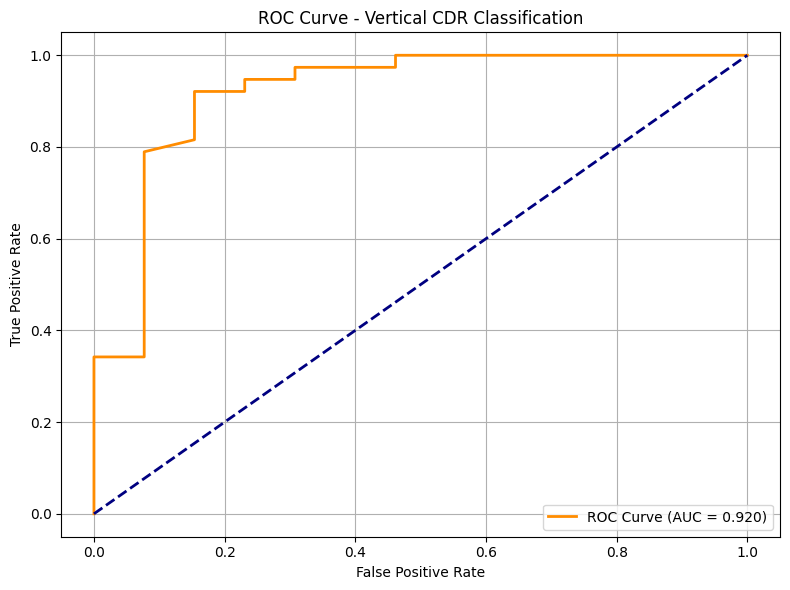

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Step 1: Labels
y_true = [0] * 13 + [1] * 38  # 13 normal, 38 glaucoma = 51

# Step 2: Replace these with your real CDR values
y_scores = [
    # 13 Normal CDRs
    0.471, 0.482, 0.491, 0.510, 0.522, 0.531, 0.567, 0.593, 0.599, 0.602, 0.650, 0.710, 0.822,

    # 38 Glaucoma CDRs
    0.571, 0.600, 0.630, 0.670, 0.690, 0.710, 0.725, 0.740, 0.750, 0.760, 0.770, 0.780, 0.790,
    0.800, 0.810, 0.820, 0.830, 0.840, 0.850, 0.860, 0.870, 0.880, 0.890, 0.900, 0.906,
    0.770, 0.680, 0.795, 0.843, 0.816, 0.866, 0.877, 0.889, 0.720, 0.690, 0.740, 0.780, 0.800
]

# Step 3: Validate lengths
print(f"Labels: {len(y_true)}, CDR Scores: {len(y_scores)}")  # Should both be 51

# Step 4: ROC curve
fpr, tpr, thresholds = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

# Step 5: Plot
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--', lw=2)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Vertical CDR Classification')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.savefig('roc_curve_vertical_cdr.png')
plt.show()
